In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
WORK_DIR="/home/magnolia/DataScience/Stellar_Class"
TRAIN_PATH=Path(WORK_DIR,"data/train.csv")
TEST_PATH=Path(WORK_DIR, "data/test.csv")
MODEL_DIR=Path(WORK_DIR,"models")

In [16]:
df=pd.read_csv(TRAIN_PATH).set_index('id')
target=df['class']
df=df.drop('class', axis=1)
features=df.columns
target_map={"GALAXY":0, "QSO":1, "STAR":2}

In [18]:
df=df.drop(['alpha', 'delta', 'spectral_type', 'galaxy_population'], axis=1)

In [ ]:
# Random sample 1000 data points from original data
import random
from sklearn.model_selection import train_test_split

random.seed(10)
idx=random.sample(range(len(df)), 1000)

X=df.to_numpy()[idx]
y=target[idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=10)
X_train.shape, X_test.shape

In [ ]:
from sklearn.svm import SVC

SVCLF=SVC()
SVCLF.fit(X_train, y_train)
SVCLF.score(X_train, y_train), SVCLF.score(X_test, y_test)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
y_map=y.map(target_map)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_map, alpha=0.75, marker='+')

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
PF=PolynomialFeatures(degree=2)
X_pf=PF.fit_transform(X)
X_pf_pca=pca.fit_transform(X_pf)
plt.scatter(X_pf_pca[:,0], X_pf_pca[:,1], c=y_map, alpha=0.75, marker='+')

In [ ]:
# Train SVC on Principal Components?
from sklearn.svm import SVC
SVClf=SVC()
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_map, random_state=10)
SVClf.fit(X_train, y_train)
print(f"Train R^2: {SVClf.score(X_train, y_train)}\nTest R^2: {SVClf.score(X_test, y_test)}")

In [ ]:
from sklearn.metrics import balanced_accuracy_score
y_pred=SVClf.predict(X_test)
print(f"Balanced Accuracy Score: {round(balanced_accuracy_score(y_test, y_pred), 2)}")

In [ ]:
# Try DBSCAN?
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=0.4, min_samples=5)
y_pred=dbscan.fit_predict(X_train)

fig, axes= plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, marker='+')
axes[1].scatter(X_train[:,0], X_train[:,1], c=y_pred, marker='+')

In [ ]:
plt.scatter(dbscan.components_[:,0], dbscan.components_[:,1], 
            c=y_map.iloc[dbscan.core_sample_indices_], alpha=0.75, marker='+')

In [ ]:
from sklearn.svm import LinearSVC

linear_svclf=LinearSVC()
linear_svclf.fit(X_train, y_train)
print(f"Train R^2: {linear_svclf.score(X_train, y_train)},\nTest R^2: {linear_svclf.score(X_test, y_test)}")

In [11]:
# random sample 100,000 samples! 
import random
from sklearn.model_selection import train_test_split

idx=random.sample(range(len(df)), 250000)
X=df.iloc[idx,:]
y=target.iloc[idx]
y=y.map(target_map)

# Split data
X_train, X_test, y_train, y_test=train_test_split(X, y, 
                                                  stratify=y, 
                                                  test_size=0.3, 
                                                  random_state=10)

In [ ]:
# Import SVC
from sklearn.svm import SVC
kernels=['linear', 'rbf', 'poly', 'sigmoid']
train_score_=[]
test_score_=[]
for kernel in kernels:
    svclf=SVC(kernel=kernel, degree=3, break_ties=True)
    svclf.fit(X_train, y_train)
    train_score_.append(svclf.score(X_train, y_train))
    test_score_.append(svclf.score(X_test, y_test))

df_svclf1=pd.DataFrame({"k": kernels, "train": train_score_, "test": test_score_})

In [ ]:
df_svclf1

In [ ]:
# break ties = False ??
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

kernels=['linear', 'rbf', 'poly', 'sigmoid']
train_score_=[]
test_score_=[]
BA_score_=[]
for kernel in kernels:
    svclf=SVC(kernel=kernel, degree=3, break_ties=False)
    svclf.fit(X_train, y_train)
    train_score_.append(svclf.score(X_train, y_train))
    test_score_.append(svclf.score(X_test, y_test))
    y_pred=svclf.predict(X_test)
    BA_score_.append(balanced_accuracy_score(y_test, y_pred))

df_svclf2=pd.DataFrame({"k": kernels, "train": train_score_, "test": test_score_, "BA": BA_score_})

In [ ]:
df_svclf2 

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

SVClf=SVC(kernel='rbf', degree=3, break_ties=True, random_state=10)
SVClf.fit(X_train, y_train)
y_pred=SVClf.predict(df)
print(f"Balanced Accuracy Score: {balanced_accuracy_score(target.map(target_map), y_pred)}")

Balanced Accuracy Score: 0.9064758297227757


In [19]:
X=df
y=target.map(target_map)
SVClf=SVC(kernel='rbf', degree=3, break_ties=True, random_state=10)
SVClf.fit(X, y)

SVC(break_ties=True, random_state=10)

In [20]:
y_pred=SVClf.predict(X)
balanced_accuracy_score(y, y_pred)

0.9111155846631918

In [22]:
MODEL_DIR

PosixPath('/home/magnolia/DataScience/Stellar_Class/models')

In [23]:
joblib.dump(SVClf ,Path(MODEL_DIR,"SVC_NO_CAT_COLS.joblib"))

['/home/magnolia/DataScience/Stellar_Class/models/SVC_NO_CAT_COLS.joblib']

In [34]:
# explore incorrect predictions
df_incorrect=df[target.map(target_map)!=y_pred]
target_incorrect=target[target.map(target_map)!=y_pred]

df_correct=df[target.map(target_map)==y_pred]
target_correct=target[target.map(target_map)==y_pred]

In [ ]:
df_correct.describe()

In [ ]:
df_incorrect.describe()

In [65]:
def plot_kde_pairs(dataframe1, dataframe2, column, target1=None, target2=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,2))
    sns.kdeplot(data=dataframe1, x=column, hue=target1, ax=ax1)
    sns.kdeplot(data=dataframe2, x=column, hue=target2, ax=ax2)
    plt.show()

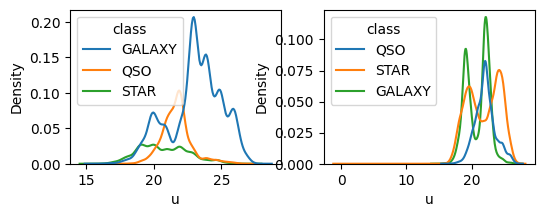

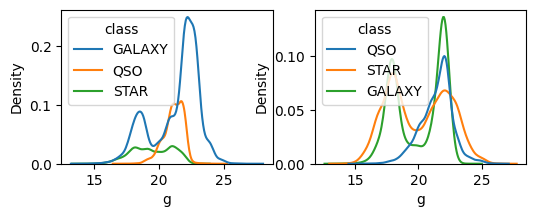

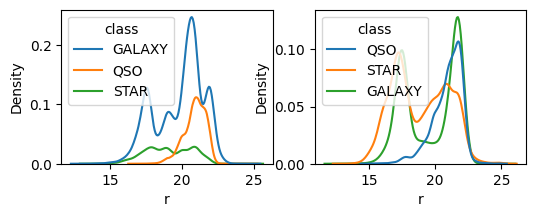

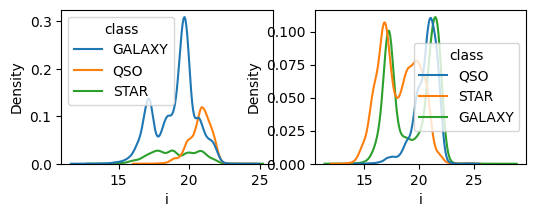

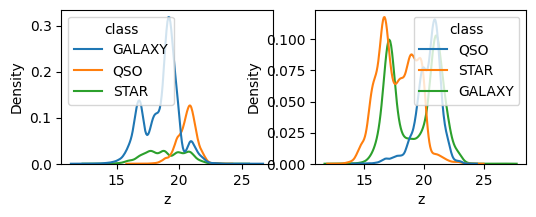

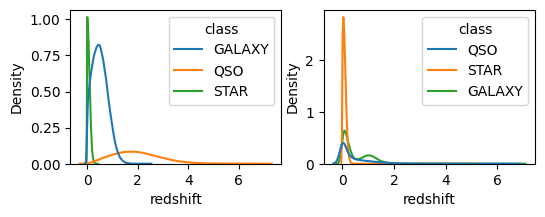

In [70]:
for col in df_correct.columns:
    plot_kde_pairs(dataframe1=df_correct, dataframe2=df_incorrect, 
                   column=col, target1=target_correct, target2=target_incorrect )

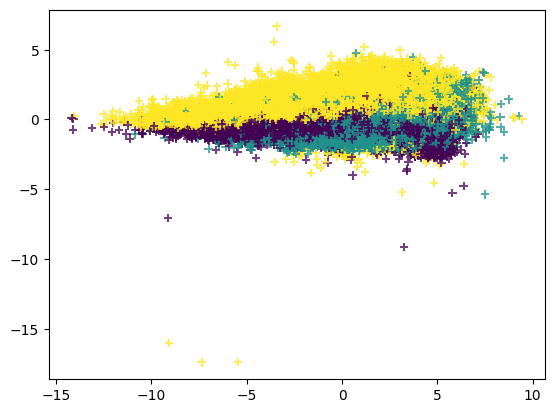

In [124]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
df_incorrect_pca=pca.fit_transform(df_incorrect)
plt.scatter(df_incorrect_pca[:,0], 
            df_incorrect_pca[:,1], 
            c=target_incorrect.map(target_map),
            marker='+', alpha=0.75)

In [117]:
# Can I apply GMM on incorrect predictions and see where it leads me? 
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
X_train, X_test, y_train, y_test=train_test_split(df_incorrect, 
                 target_incorrect.map(target_map), 
                 stratify=target_incorrect,
                 random_state=10)
gmm=GaussianMixture(n_components=3, covariance_type='full', init_params='k-means++')
gmm.fit(X_train, y_train)
y_pred=gmm.predict(X_test)
balanced_accuracy_score(y_test, y_pred)

0.3504788509610533

0.3333333333333333

(3, 6, 6)